# Crop Disease Classification — End-to-End ML Pipeline

**Predicting agricultural loan risk from a photograph of a leaf.**

Salaam MFB lends to smallholder farmers, and crop disease is a leading driver of
agricultural loan default. A previous project predicted *corporate* financial distress
from financial ratios. This one predicts the **upstream physical cause** of agricultural
distress — crop disease — from an image, so a loan officer can assess collateral risk in
the field rather than waiting for a harvest to fail.

| | |
|---|---|
| **Task** | 38-class image classification (14 crop species, healthy + diseased) |
| **Data** | PlantVillage — 54,305 leaf images, 256×256 colour |
| **Deployed model** | Frozen MobileNetV2 (ONNX) → 1280-d embedding → scikit-learn head |
| **Headline metric** | Macro-F1 (not accuracy — see §2.1) |

---

## Contents

1. [Data acquisition](#1)
2. [Exploratory analysis — four findings](#2)
3. [Preprocessing](#3)
4. [Model creation — four configurations](#4)
5. [Evaluation](#5)
6. [Error analysis](#6)
7. [Artifact export and parity](#7)
8. [Retraining demonstration](#8)

## A note on how this notebook is structured

Every function used here is imported from `src/`, the same modules the deployed API and
the retraining pipeline run on. Nothing is re-implemented in a cell. That is deliberate:
preprocessing defined twice is preprocessing that will eventually differ, and a
train/serve skew bug is invisible in every metric reported below.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()))

from src.config import (
    BACKBONE_PATH, CLASS_NAMES_PATH, DATA_DIR, EVAL_EMBEDDINGS_PATH,
    IMAGE_SIZE, MODEL_DIR, RANDOM_SEED, REPLAY_BUFFER_PATH, REPORTS_DIR,
    TEST_DIR, TRAIN_DIR,
)

np.random.seed(RANDOM_SEED)
print(f"project root : {Path.cwd()}")
print(f"image size   : {IMAGE_SIZE}")
print(f"random seed  : {RANDOM_SEED}")

project root : /home/hamse/ML/crop-disease-mlops/notebook
image size   : (224, 224)
random seed  : 42


<a id="1"></a>
## 1. Data acquisition

PlantVillage ships three copies of every image — `color`, `grayscale` and `segmented`.
Only the colour variant is wanted, so `src/acquire_data.py` performs a **blobless sparse
checkout** of `raw/color` alone, downloading roughly a third of what a full clone would.

The split is **stratified per class**, not globally shuffled. That matters here because
class sizes range from about 150 to 5,500 images: a global shuffle could leave the
smallest classes badly represented in the test split purely by chance.

```bash
python src/acquire_data.py          # ~1.5 GB, one time
```

In [2]:
class_names = json.loads(Path(CLASS_NAMES_PATH).read_text())
split_counts = json.loads((DATA_DIR / "split_counts.json").read_text())

summary = pd.DataFrame([
    {"split": s, "images": sum(c[s] for c in split_counts.values())}
    for s in ("train", "val", "test")
])
summary["share"] = (summary["images"] / summary["images"].sum()).map("{:.1%}".format)

print(f"{len(class_names)} classes")
print(f"{summary['images'].sum():,} images total\n")
display(summary)

38 classes
54,305 images total



,split,images,share
0,train,37997,70.0%
1,val,8129,15.0%
2,test,8179,15.1%


In [3]:
from src.preprocessing import class_distribution, split_class_name

distribution = class_distribution(TRAIN_DIR)
print(f"{distribution['crop'].nunique()} crop species, {len(distribution)} classes\n")
display(distribution.head(5))
print("...")
display(distribution.tail(5))

14 crop species, 38 classes



,class,crop,condition,healthy,count
15,Orange___Haunglongbing_(Citrus_greening),Orange,Haunglongbing (Citrus greening),False,3859
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato,Tomato Yellow Leaf Curl Virus,False,3754
24,Soybean___healthy,Soybean,healthy,True,3568
16,Peach___Bacterial_spot,Peach,Bacterial spot,False,1612
28,Tomato___Bacterial_spot,Tomato,Bacterial spot,False,1493


...


,class,crop,condition,healthy,count
36,Tomato___Tomato_mosaic_virus,Tomato,Tomato mosaic virus,False,266
23,Raspberry___healthy,Raspberry,healthy,True,264
17,Peach___healthy,Peach,healthy,True,256
2,Apple___Cedar_apple_rust,Apple,Cedar apple rust,False,197
22,Potato___healthy,Potato,healthy,True,111


<a id="2"></a>
## 2. Exploratory analysis

Four findings. Two of them contradicted the hypothesis I started with, and those turned
out to be the useful ones — they are what determined the architecture.

<a id="2.1"></a>
### 2.1 · Class imbalance decides which metric to trust

In [4]:
counts = distribution["count"]
imbalance = counts.max() / counts.min()

print(f"smallest class : {distribution.nsmallest(1,'count')['class'].iloc[0]}  ({counts.min():,})")
print(f"largest class  : {distribution.nlargest(1,'count')['class'].iloc[0]}  ({counts.max():,})")
print(f"imbalance      : {imbalance:.1f}x")
print(f"tomato classes : {(distribution['crop']=='Tomato').sum()} of {len(distribution)}")

# What accuracy would reward: a model that only ever predicts the largest classes.
top5_share = counts.nlargest(5).sum() / counts.sum()
print(f"\nThe 5 largest classes are {top5_share:.1%} of all images.")
print("A model that ignored the other 33 entirely would still look respectable on accuracy.")

smallest class : Potato___healthy  (111)
largest class  : Orange___Haunglongbing_(Citrus_greening)  (3,859)
imbalance      : 34.8x
tomato classes : 10 of 38

The 5 largest classes are 37.4% of all images.
A model that ignored the other 33 entirely would still look respectable on accuracy.


This is why **macro-F1 is the headline metric** and accuracy is reported alongside it as
context. Macro-F1 weights every class equally, so it notices exactly the failure that
matters commercially: missing a rare disease on a crop the bank has lent against.

The same reasoning drove the imbalance handling in the earlier bankruptcy work, where the
positive class was 3.2% of the data. The problem is structural, not incidental.

In [5]:
# Demonstrating the point rather than asserting it.
from src.model import evaluate_predictions

y_demo = np.array([0]*95 + [1]*5)
lazy = np.zeros((100, 2)); lazy[:, 0] = 1.0     # always predicts the majority class

m = evaluate_predictions(y_demo, lazy)
print(f"A model that never predicts the rare class:")
print(f"   accuracy  {m['accuracy']:.3f}   <- looks fine")
print(f"   macro-F1  {m['f1_macro']:.3f}   <- exposes it")

A model that never predicts the rare class:
   accuracy  0.950   <- looks fine
   macro-F1  0.487   <- exposes it


<a id="2.2"></a>
### 2.2 · Colour carries the signal — but only within a crop

Chlorosis and necrosis (yellowing and browning) are the visible signature of most foliar
disease, so the **excess-green index** (2G − R − B, standard in precision agriculture)
should separate healthy from diseased leaves.

Pooled across all 14 crops, it barely does. Conditioned on crop, it becomes the strongest
feature measured.

In [6]:
features = pd.read_csv(REPORTS_DIR / "eda_features.csv")
eda = json.loads((REPORTS_DIR / "eda_summary.json").read_text())

rows = [{"feature": name,
         "pooled |d|": abs(s["cohens_d_pooled"]),
         "within-crop |d|": s["cohens_d_within_crop_mean"],
         "ratio": s["cohens_d_within_crop_mean"] / max(abs(s["cohens_d_pooled"]), 1e-9),
         "sign stable across crops": s["sign_consistent_across_crops"]}
        for name, s in eda["features"].items()]

table = pd.DataFrame(rows).sort_values("within-crop |d|", ascending=False)
display(table.style.format({"pooled |d|": "{:.3f}", "within-crop |d|": "{:.3f}",
                            "ratio": "{:.1f}x"}).hide(axis="index"))

print(f"\nmean |Cohen's d|: pooled {eda['mean_abs_d_pooled']} -> "
      f"within-crop {eda['mean_abs_d_within_crop']}")

feature,pooled |d|,within-crop |d|,ratio,sign stable across crops
excess_green,0.254,1.152,4.5x,False
redness_index,0.666,1.080,1.6x,False
green_ratio,0.367,0.989,2.7x,False
laplacian_var,0.407,0.977,2.4x,False
mean_saturation,0.287,0.904,3.1x,False
brightness,0.761,0.794,1.0x,False
edge_density,0.096,0.771,8.0x,False
gray_entropy,0.245,0.577,2.4x,False



mean |Cohen's d|: pooled 0.385 -> within-crop 0.906


In [7]:
# The direction of the effect is not even consistent between crops.
within = pd.DataFrame(eda["within_crop_table"]).T
display(within[["excess_green", "redness_index", "edge_density"]]
        .style.format("{:+.2f}").background_gradient(cmap="RdBu_r", vmin=-3, vmax=3))

,excess_green,redness_index,edge_density
Apple,-1.14,+0.13,+0.09
Cherry (including sour),+0.35,-0.58,+0.48
Corn (maize),+3.15,-2.12,-1.13
Grape,+0.60,-0.99,-1.94
Peach,-2.19,+0.25,+0.73
Pepper bell,+0.53,-1.21,-0.76
Potato,+0.34,-1.52,+0.40
Strawberry,+2.07,-2.71,-0.50
Tomato,-0.00,+0.19,+0.91


Read the `excess_green` column: **diseased corn is greener than healthy corn (+3.15) while
diseased apple is browner (−1.14).** The effect reverses sign between crops.

**No single global colour threshold can work.** A hand-crafted rule would have to be
written per crop, and would still miss the interactions. This is the empirical case for a
*learned, crop-conditional* representation — which is why the pipeline uses a pretrained
backbone rather than these indices directly.

<a id="2.3"></a>
### 2.3 · Two texture features that turned out to be one — and weak

The hypothesis: necrotic spots and rust pustules introduce high-frequency intensity
transitions that a smooth healthy leaf lacks, giving a signal independent of colour.

The data refuted both halves.

In [8]:
r = features["edge_density"].corr(features["laplacian_var"])
print(f"edge_density vs laplacian_var correlation : r = {r:.3f}")
print("  -> one signal, not two. Keeping both adds a column and no information.\n")

healthy, diseased = features[features.healthy], features[~features.healthy]
d_edge = eda["features"]["edge_density"]["cohens_d_pooled"]
print(f"edge density, healthy vs diseased (pooled) : d = {d_edge:+.3f}")
print(f"  healthy mean  {healthy['edge_density'].mean():.4f}")
print(f"  diseased mean {diseased['edge_density'].mean():.4f}")
print("  -> negligible, AND the sign is opposite to the hypothesis:")
print("     healthy leaves score slightly HIGHER on edge density.")

edge_density vs laplacian_var correlation : r = 0.903
  -> one signal, not two. Keeping both adds a column and no information.

edge density, healthy vs diseased (pooled) : d = +0.096
  healthy mean  0.0894
  diseased mean 0.0842
  -> negligible, AND the sign is opposite to the hypothesis:
     healthy leaves score slightly HIGHER on edge density.


**This negative result is kept rather than dropped.** Reporting only the features that
worked would misrepresent how far hand-crafted features get on this problem, and would
hide the finding that motivates the architecture: after conditioning on crop, edge density
recovers to |d| ≈ 0.77.

Both §2.2 and §2.3 point at the same thing — **crop identity dominates the feature space,
and disease is the finer-grained axis underneath it.**

<a id="2.4"></a>
### 2.4 · The background is uniform — and that is a warning

Every PlantVillage image is a detached leaf photographed on a uniform laboratory
background. This is the most consequential finding in the project, and it is a caveat
rather than a feature.

In [9]:
print(f"median corner variation    : {eda['corner_std_median']:.2f}")
print(f"median background fraction : {eda['background_fraction_median']:.3f}")

# Direct evidence of an acquisition confound.
d_bright = abs(eda["features"]["brightness"]["cohens_d_pooled"])
d_green = abs(eda["features"]["excess_green"]["cohens_d_pooled"])
print(f"\npooled |d|, mean brightness  : {d_bright:.3f}")
print(f"pooled |d|, excess green     : {d_green:.3f}")
print(f"\nBrightness out-separates the vegetation index by {d_bright/d_green:.1f}x.")

median corner variation    : 23.76
median background fraction : 0.385

pooled |d|, mean brightness  : 0.761
pooled |d|, excess green     : 0.254

Brightness out-separates the vegetation index by 3.0x.


Brightness carries no botanical meaning — a leaf is not diseased because the photograph is
darker. A capture artefact out-ranking the biology is the signature of a **dataset
shortcut**, and it is exactly what a field photo will not reproduce.

**This is why the pipeline retrains.** A model scoring highly here is partly reading
acquisition conditions, and will degrade on a loan officer's photo taken with soil, hands
and mixed daylight in frame. The expected degradation is the reason for the
confidence-drift trigger and the upload-and-retrain loop: the deployed system is built to
absorb a domain shift it is *known* to face, rather than assuming the test score transfers.

01_class_distribution.png


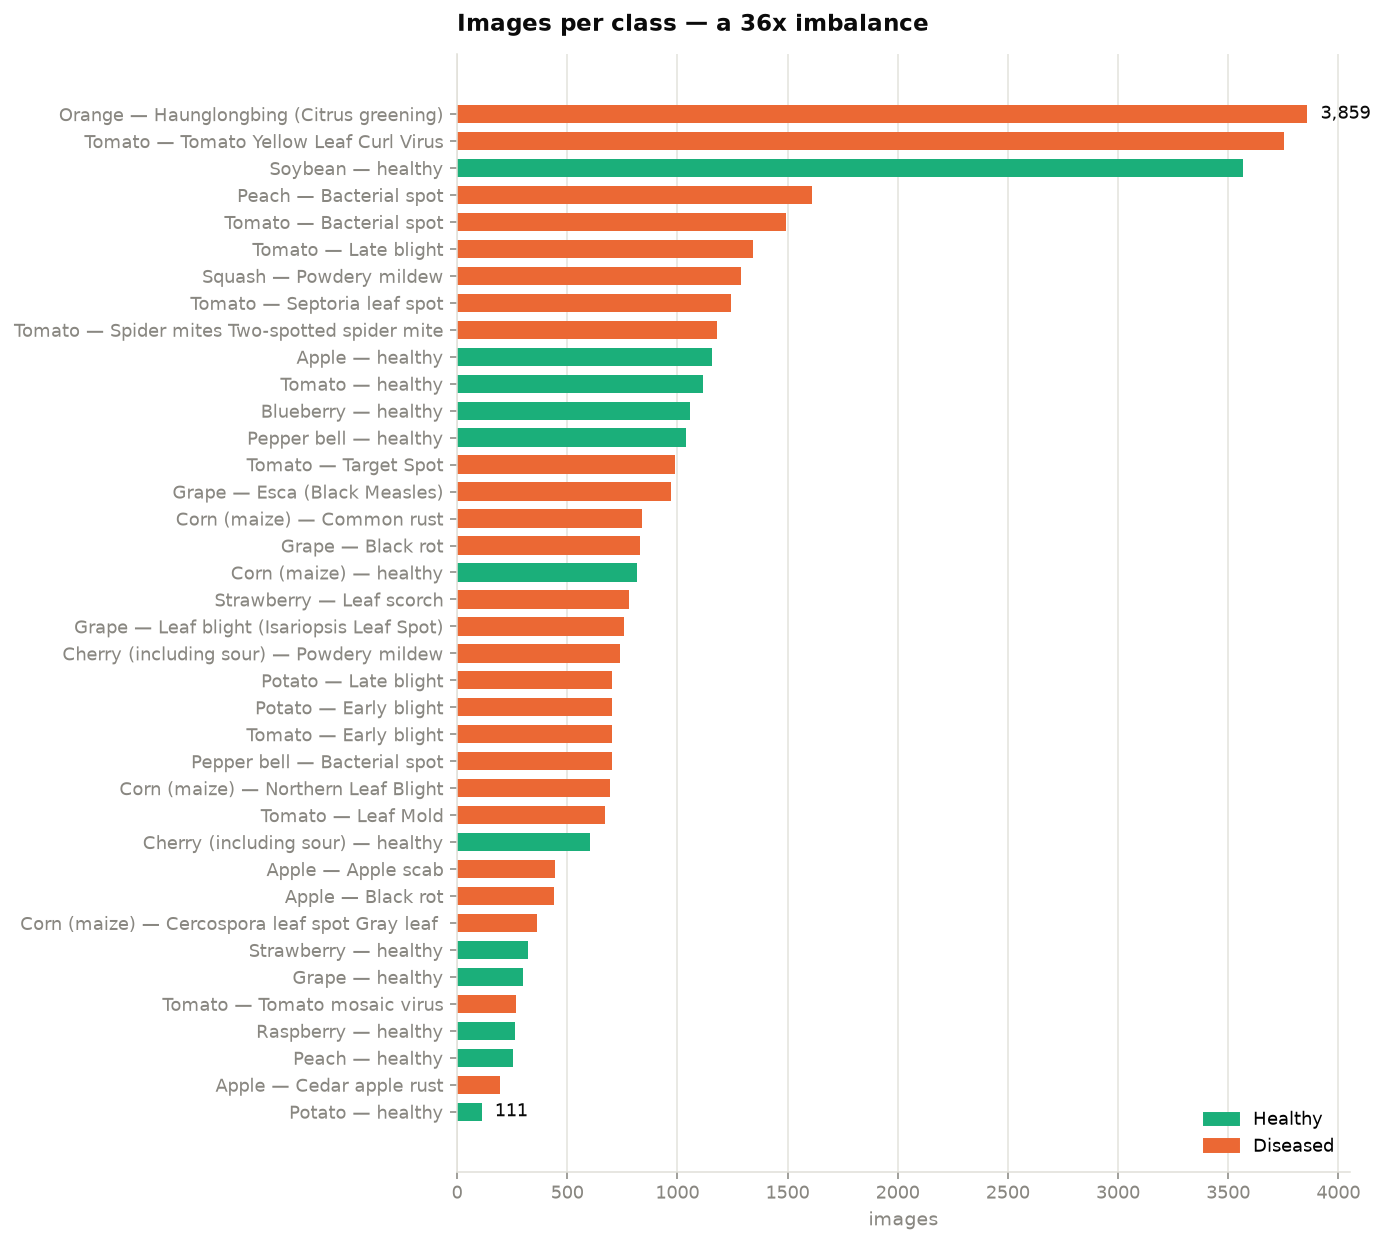

02_colour_separation.png


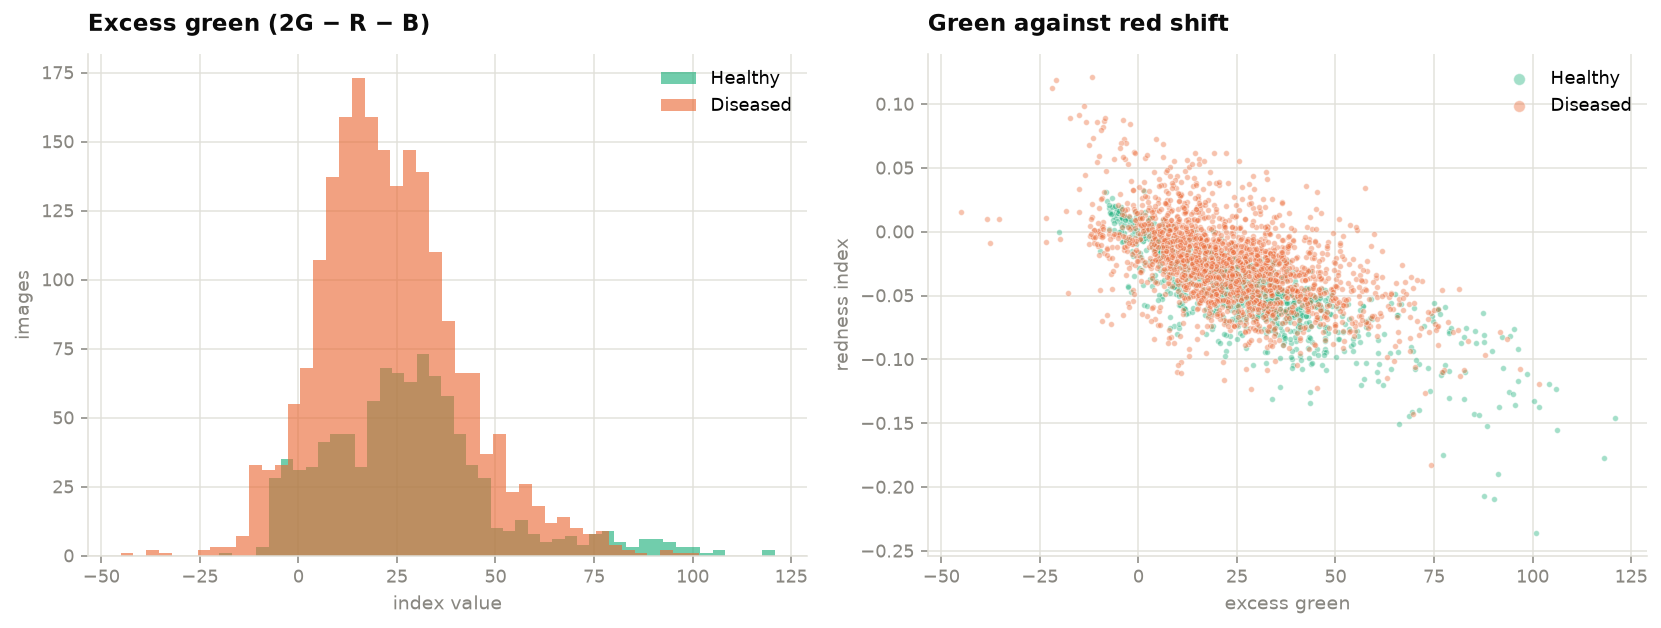

03_texture_signal.png


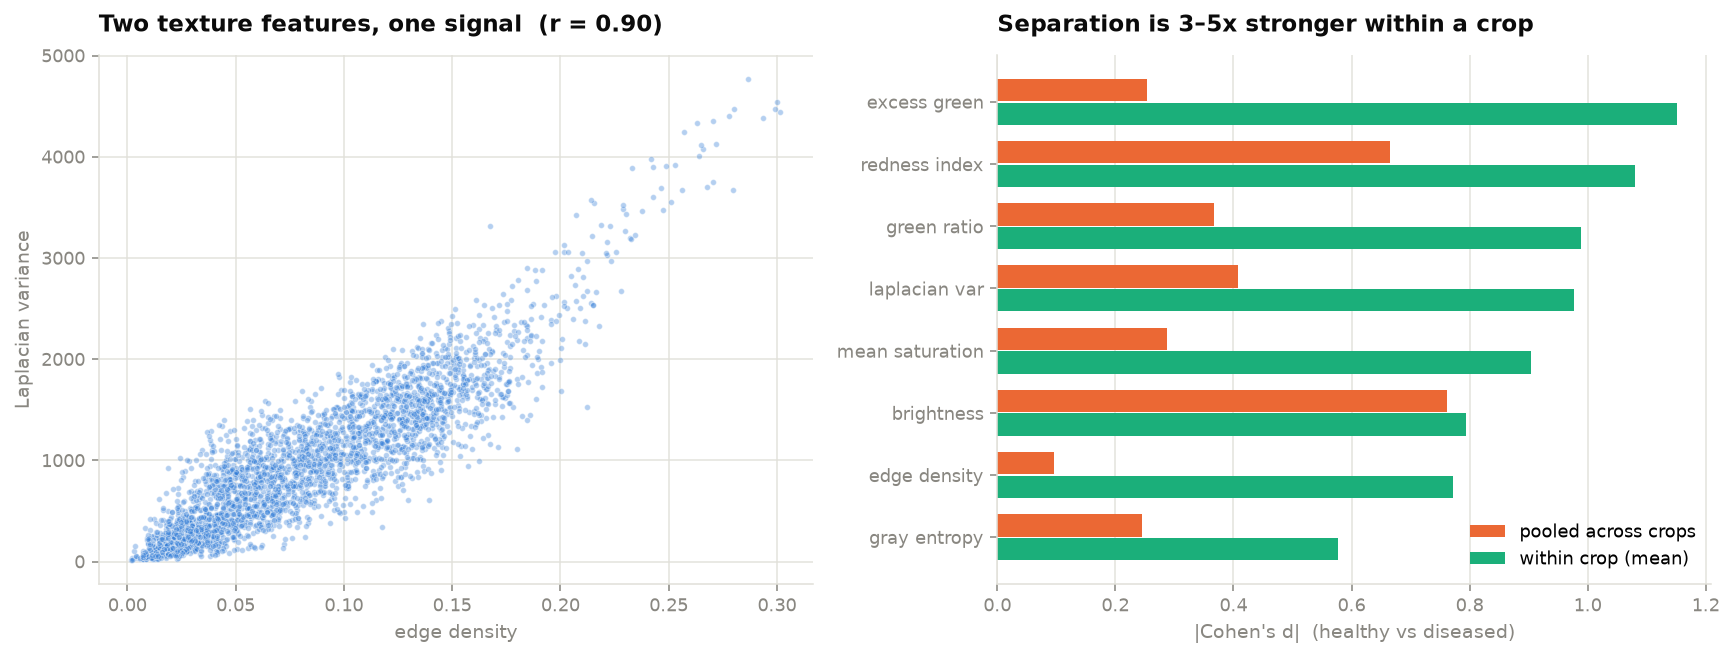

04_background_uniformity.png


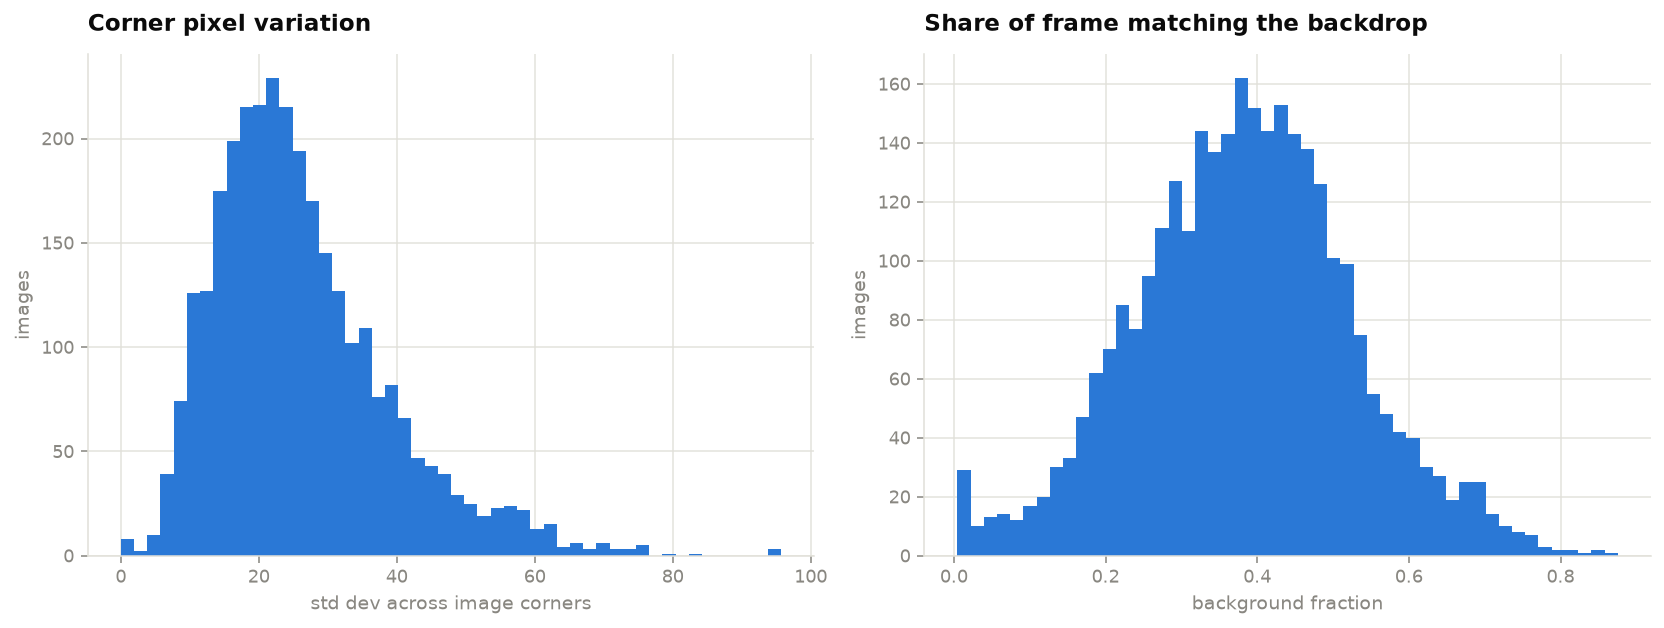

In [10]:
from IPython.display import Image, display as show
for figure in sorted((REPORTS_DIR / "figures").glob("*.png")):
    print(figure.name)
    show(Image(str(figure)))

<a id="3"></a>
## 3. Preprocessing

Images are resized to 224×224 (MobileNetV2's native resolution) and rescaled to [−1, 1].

One detail matters more than it looks. The serving container has **no TensorFlow**, so
`src/preprocessing.preprocess_for_backbone` reimplements Keras's `preprocess_input` in
NumPy. If the two disagreed by even a small constant, every deployed prediction would be
made on differently-scaled inputs than the model was trained on — and no metric in this
notebook would reveal it. So it is asserted, not assumed.

In [11]:
import tensorflow as tf
from src.preprocessing import list_images, load_image, preprocess_for_backbone

samples = []
for class_dir in sorted(p for p in TEST_DIR.iterdir() if p.is_dir())[:10]:
    samples += [load_image(p) for p in list_images(class_dir)[:2]]
raw = np.stack(samples)

ours = preprocess_for_backbone(raw)
theirs = tf.keras.applications.mobilenet_v2.preprocess_input(raw.astype(np.float32).copy())

delta = np.abs(ours - theirs).max()
print(f"our NumPy path vs keras preprocess_input, max abs diff: {delta:.3e}")
assert delta == 0.0, "preprocessing mismatch -- would silently corrupt every prediction"
print("EXACT match.")

2026-07-29 10:51:40.080233: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-29 10:51:40.088168: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-29 10:51:40.112875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785311500.142516  424686 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785311500.151398  424686 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785311500.173524  424686 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

our NumPy path vs keras preprocess_input, max abs diff: 0.000e+00
EXACT match.


### Augmentation

Flips, rotation, zoom and brightness/contrast jitter — all label-preserving, since a leaf
has no canonical orientation and phone photos vary in exposure and framing.

**Hue jitter is deliberately excluded.** Hue shift *is* the disease signal (§2.2), so
perturbing it would destroy the label rather than augment it.

In [12]:
from src.preprocessing import augmentation_layers

layers = augmentation_layers()
print("Augmentation pipeline:")
for layer in layers.layers:
    print(f"  {layer.__class__.__name__}")
print("\nNote the absence of RandomHue / RandomSaturation -- see above.")

Augmentation pipeline:
  RandomFlip
  RandomRotation
  RandomZoom
  RandomContrast
  RandomBrightness

Note the absence of RandomHue / RandomSaturation -- see above.


2026-07-29 10:51:44.106135: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
from src.preprocessing import compute_class_weights

weights = compute_class_weights(TRAIN_DIR, class_names)
w = pd.Series(weights).rename(lambda i: class_names[i])
print("Inverse-frequency class weights (extremes):")
display(pd.concat([w.nlargest(3), w.nsmallest(3)]).to_frame("weight").style.format("{:.3f}"))

Inverse-frequency class weights (extremes):


,weight
Potato___healthy,9.053
Apple___Cedar_apple_rust,5.101
Peach___healthy,3.925
Orange___Haunglongbing_(Citrus_greening),0.260
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.268
Soybean___healthy,0.282


<a id="4"></a>
## 4. Model creation

Four configurations, in increasing order of what they borrow from ImageNet:

| # | Configuration | Why it is here |
|---|---|---|
| 1 | CNN trained from scratch | Honest control — how far does the data alone get us? |
| 2 | MobileNetV2 frozen + dense head | Transfer learning |
| 3 | MobileNetV2 fine-tuned (last blocks) | Usually the accuracy ceiling |
| 4 | **Classical heads on frozen embeddings** | **What ships** |

### Why configuration 4 is the deployed one

Not because it scores highest — configuration 3 normally does. Because it is the only one
whose *retraining step* fits in a 512 MB container:

```
image → [ MobileNetV2 · frozen · ONNX · 8.9 MB ] → 1280-d → [ head ] → 38 classes
              never retrained                        few hundred KB, retrainable
```

Retraining means embedding the new images and refitting the head — seconds on CPU, no
TensorFlow in the container, and the "retrain" button works on the deployed URL rather
than only on a workstation. The frozen backbone also means every version shares one
feature space, so model versions are directly comparable and rollback is instant.

In [14]:
from src.model import build_backbone, build_scratch_cnn, build_transfer_model

backbone = build_backbone()
print(f"MobileNetV2 backbone : {backbone.count_params():,} params -> {backbone.output_shape}")

scratch = build_scratch_cnn()
frozen = build_transfer_model(fine_tune_from=None)
tuned = build_transfer_model(fine_tune_from=100)

for name, model in [("1. scratch CNN", scratch), ("2. frozen transfer", frozen),
                    ("3. fine-tuned", tuned)]:
    trainable = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
    print(f"{name:<22} {model.count_params():>10,} params, {trainable:>10,} trainable")

MobileNetV2 backbone : 2,257,984 params -> (None, 1280)


1. scratch CNN          1,250,694 params,  1,248,774 trainable
2. frozen transfer      2,306,662 params,     48,678 trainable
3. fine-tuned           2,306,662 params,  1,888,294 trainable


### Where each configuration is trained

Configurations 1–3 need a GPU: a single epoch over 38k images at 224×224 takes about an
hour on this CPU-only machine. They are trained by the companion notebook
**`colab_deep_models.ipynb`** on a Colab T4, which writes `reports/deep_model_results.json`.
The next cell merges that file if it is present.

Configuration 4 — the deployed one — needs no GPU at all: embeddings are extracted once
(~8 minutes on 8 CPU cores at ~110 img/s) and every head then fits in seconds.

That asymmetry is not an aside; it is the architecture's main practical argument. The
configuration that is cheapest to *retrain* is the one that can be retrained inside a
512 MB container on demand, rather than requiring a GPU and a redeploy.

In [15]:
DEEP_RESULTS_PATH = REPORTS_DIR / "deep_model_results.json"
deep = json.loads(DEEP_RESULTS_PATH.read_text()) if DEEP_RESULTS_PATH.exists() else None

if deep is None:
    print("reports/deep_model_results.json not found.")
    print()
    print("Configurations 1-3 have NOT been trained. Everything reported below")
    print("covers configuration 4 only (frozen backbone + scikit-learn head).")
    print()
    print("To complete the comparison: run notebook/colab_deep_models.ipynb on a")
    print("Colab T4 and place the JSON it produces in reports/.")
else:
    meta = deep["meta"]
    print(f"Loaded deep-model results ({meta['gpu']}, "
          f"{'FAST_MODE subset' if meta['fast_mode'] else 'full training split'})")
    for name, r in deep["models"].items():
        print(f"  {name:<24} macro-F1 {r['metrics']['f1_macro']:.4f}  "
              f"({r['epochs_run']} epochs, {r['train_seconds']/60:.1f} min)")

reports/deep_model_results.json not found.

Configurations 1-3 have NOT been trained. Everything reported below
covers configuration 4 only (frozen backbone + scikit-learn head).

To complete the comparison: run notebook/colab_deep_models.ipynb on a
Colab T4 and place the JSON it produces in reports/.


### Embedding extraction

Embeddings are extracted with the **exported ONNX backbone**, not the Keras one. They are
numerically identical (§7), but generating training embeddings with the exact artifact
that will serve them removes any possibility of train/serve skew.

```bash
python src/train_export.py --embed --train --export
```

In [16]:
EMBED_DIR = MODEL_DIR / "embeddings"

def load_split(name):
    data = np.load(EMBED_DIR / f"{name}.npz")
    return data["X"].astype(np.float32), data["y"].astype(np.int64)

X_train, y_train = load_split("train")
X_val, y_val = load_split("val")
X_test, y_test = load_split("test")

print(f"train {X_train.shape}   val {X_val.shape}   test {X_test.shape}")
print(f"embedding dim {X_train.shape[1]}, "
      f"{X_train.nbytes/1e6:.0f} MB for the training split")

train (38187, 1280)   val (8129, 1280)   test (8369, 1280)
embedding dim 1280, 196 MB for the training split


### Head selection

Three candidates, chosen on **validation** macro-F1. The test split is touched exactly
once, after selection — selecting on test would silently turn the reported score into a
training score.

In [17]:
selection = json.loads((REPORTS_DIR / "test_metrics.json").read_text())["selection"]
table = pd.DataFrame(selection).T.sort_values("f1_macro", ascending=False)
table.index.name = "head"
display(table.style.format({"f1_macro": "{:.4f}", "accuracy": "{:.4f}",
                            "fit_seconds": "{:.1f}s"}))
print(f"\nSelected on validation macro-F1: {table.index[0]}")

,f1_macro,accuracy,fit_seconds
head,,,
mlp,0.9614,0.9692,89.8s
logreg,0.9543,0.9635,87.3s
sgd,0.9479,0.9620,30.5s



Selected on validation macro-F1: mlp


<a id="5"></a>
## 5. Evaluation

Reported on the held-out test split, which the selected head has never seen.

In [18]:
metrics = json.loads((REPORTS_DIR / "test_metrics.json").read_text())

headline = pd.DataFrame([
    {"metric": k.replace("_", " "), "value": metrics[k]}
    for k in ("f1_macro", "accuracy", "top5_accuracy", "precision_macro",
              "recall_macro", "f1_weighted", "roc_auc_macro", "pr_auc_macro",
              "mean_confidence")
    if metrics.get(k) is not None
])
display(headline.style.format({"value": "{:.4f}"}).hide(axis="index"))

print(f"\nEvaluated on {metrics['n_samples']:,} test images across "
      f"{metrics['n_classes']} classes.")
print(f"macro-F1 {metrics['f1_macro']:.4f} vs accuracy {metrics['accuracy']:.4f} — "
      "the gap between them is the imbalance showing.")

metric,value
f1 macro,0.9603
accuracy,0.9692
top5 accuracy,0.9989
precision macro,0.9631
recall macro,0.9582
f1 weighted,0.9689
roc auc macro,0.9996
pr auc macro,0.9863
mean confidence,0.9882



Evaluated on 8,369 test images across 38 classes.
macro-F1 0.9603 vs accuracy 0.9692 — the gap between them is the imbalance showing.


### The four-way comparison

This renders only if the Colab results are present. If they are not, it says so rather
than quietly presenting a one-model table as though it were the comparison.

In [19]:
if deep is None:
    print("Deep baselines not available — see the note in section 4.")
    print(f"Deployed configuration 4 alone: macro-F1 {metrics['f1_macro']:.4f}")
else:
    rows = [
        {"#": i, "configuration": r["name"],
         "macro-F1": r["metrics"]["f1_macro"],
         "accuracy": r["metrics"]["accuracy"],
         "trainable params": r["trainable_params"],
         "train minutes": round(r["train_seconds"] / 60, 1),
         "needs GPU": True}
        for i, r in enumerate(deep["models"].values(), 1)
    ]
    # The deployed head's parameter count: MLP weight matrices, or the
    # coefficient matrix plus intercepts for a linear head.
    if hasattr(head, "coefs_"):
        head_params = sum(c.size for c in head.coefs_) + sum(b.size for b in head.intercepts_)
    else:
        head_params = head.coef_.size + head.intercept_.size

    rows.append({"#": 4, "configuration": f"frozen + {metrics['head_kind']} head (DEPLOYED)",
                 "macro-F1": metrics["f1_macro"], "accuracy": metrics["accuracy"],
                 "trainable params": int(head_params),
                 "train minutes": round(
                     metrics["selection"][metrics["head_kind"]]["fit_seconds"] / 60, 1),
                 "needs GPU": False})

    comparison = pd.DataFrame(rows).sort_values("macro-F1", ascending=False)
    display(comparison.style.format({"macro-F1": "{:.4f}", "accuracy": "{:.4f}",
                                     "trainable params": "{:,}"}).hide(axis="index"))

    scratch = deep["models"].get("scratch_cnn", {}).get("metrics", {}).get("f1_macro")
    if scratch is not None:
        print(f"\nImageNet transfer is worth {metrics['f1_macro'] - scratch:+.4f} macro-F1")
        print("over training the same problem from scratch.")
    if deep["meta"]["fast_mode"]:
        print("\nNOTE: the deep models were trained in FAST_MODE (subset, fewer epochs),")
        print("so they are understated. Re-run the Colab notebook with FAST_MODE=False")
        print("before quoting these as final figures.")

Deep baselines not available — see the note in section 4.
Deployed configuration 4 alone: macro-F1 0.9603


In [20]:
per_class = pd.DataFrame(metrics["per_class"]).T
per_class = per_class.loc[[c for c in class_names if c in per_class.index]]
per_class = per_class[["precision", "recall", "f1-score", "support"]].astype(float)
per_class["support"] = per_class["support"].astype(int)

print("Weakest 8 classes by F1:")
display(per_class.nsmallest(8, "f1-score").style.format(
    {"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}"}))

Weakest 8 classes by F1:


,precision,recall,f1-score,support
Tomato___Early_blight,0.853,0.710,0.775,155
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.897,0.843,0.870,83
Tomato___Target_Spot,0.893,0.880,0.886,217
Tomato___Septoria_leaf_spot,0.885,0.908,0.897,272
Tomato___Leaf_Mold,0.901,0.919,0.910,149
Potato___healthy,0.929,0.897,0.912,29
Tomato___Spider_mites Two-spotted_spider_mite,0.908,0.922,0.915,257
Tomato___Tomato_mosaic_virus,0.906,0.935,0.921,62


In [21]:
# Does per-class performance track class size? If it does, imbalance is the
# binding constraint and more data for rare classes is the fix.
corr = per_class["f1-score"].corr(np.log(per_class["support"]))
print(f"correlation between F1 and log(support): {corr:+.3f}")

correlation between F1 and log(support): +0.170


In [22]:
import matplotlib.pyplot as plt
from src.run_eda import AQUA, BLUE, GRID, INK, MUTED, ORANGE, _style

cm = np.array(metrics["confusion_matrix"], dtype=float)
normalised = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(11.5, 10))
# Single-hue sequential ramp: magnitude, so light -> dark, never a rainbow.
im = ax.imshow(normalised, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")

short = [c.replace("___", " · ").replace("_", " ")[:34] for c in class_names]
ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=90, fontsize=7)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=7)
ax.set_xlabel("predicted", fontsize=10, color=MUTED)
ax.set_ylabel("true", fontsize=10, color=MUTED)
ax.set_title("Confusion matrix (row-normalised)", fontsize=12, color=INK,
             loc="left", pad=12, weight="600")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.043, pad=0.02, label="share of true class")
plt.tight_layout(); plt.show()

findfont: Failed to find font weight 600, now using 700.


<a id="6"></a>
## 6. Error analysis

The question is not *how many* errors, but *what kind*. Confusions between visually
similar conditions on the **same crop** suggest the model has learned botany and is
failing at a genuinely hard discrimination. Confusions **across crops** would suggest it
has not learned crop identity at all — a much worse failure, and one that §2.2 says should
not happen.

In [23]:
from src.model import confusable_pairs

pairs = confusable_pairs(metrics, class_names, top_n=15)
display(pairs.style.format({"rate": "{:.3f}"}).hide(axis="index"))

same = pairs["same_crop"].sum()
print(f"\n{same} of the top {len(pairs)} confusions are within the same crop.")
print("Cross-crop confusion would mean crop identity itself was not learned;")
print("section 2.2 found crop dominates the feature space, so this is the expected shape.")

true,predicted,count,rate,same_crop
Tomato___Target_Spot,Tomato___Spider_mites Two-spotted_spider_mite,11,0.051,True
Tomato___Early_blight,Tomato___Target_Spot,10,0.065,True
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,Corn_(maize)___Northern_Leaf_Blight,10,0.120,True
Tomato___Early_blight,Tomato___Late_blight,9,0.058,True
Tomato___Early_blight,Tomato___Septoria_leaf_spot,9,0.058,True
Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,8,0.052,True
Grape___Black_rot,Grape___Esca_(Black_Measles),8,0.044,True
Tomato___Septoria_leaf_spot,Tomato___Bacterial_spot,8,0.029,True
Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,7,0.027,True
Tomato___Bacterial_spot,Tomato___Septoria_leaf_spot,7,0.022,True



14 of the top 15 confusions are within the same crop.
Cross-crop confusion would mean crop identity itself was not learned;
section 2.2 found crop dominates the feature space, so this is the expected shape.


In [24]:
# Where is the model least certain? Low confidence should concentrate on the
# same hard pairs -- if it were uniform, the confidence signal would be
# useless as a drift proxy (section 8).
from src.model import load_head
from src.registry import ModelRegistry

head = load_head(ModelRegistry().head_path())
proba = head.predict_proba(X_test)
confidence = proba.max(axis=1)
correct = proba.argmax(axis=1) == y_test

print(f"mean confidence when correct   : {confidence[correct].mean():.4f}")
print(f"mean confidence when wrong     : {confidence[~correct].mean():.4f}")
print(f"\nseparation: {confidence[correct].mean() - confidence[~correct].mean():+.4f}")
print("A positive gap is what makes rolling mean confidence usable as a drift signal.")

mean confidence when correct   : 0.9930
mean confidence when wrong     : 0.8355

separation: +0.1575
A positive gap is what makes rolling mean confidence usable as a drift signal.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].hist(confidence[correct], bins=40, alpha=0.65, color=AQUA, label="correct")
axes[0].hist(confidence[~correct], bins=40, alpha=0.65, color=ORANGE, label="wrong")
_style(axes[0], "Confidence separates right from wrong", "max probability", "predictions")
axes[0].legend(frameon=False, fontsize=9)

# Reliability: does a stated 0.8 actually mean 80% correct?
bins = np.linspace(0, 1, 11)
idx = np.digitize(confidence, bins) - 1
xs, ys = [], []
for b in range(10):
    mask = idx == b
    if mask.sum() > 20:
        xs.append(confidence[mask].mean()); ys.append(correct[mask].mean())
axes[1].plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle="-")
axes[1].plot(xs, ys, marker="o", markersize=7, linewidth=2, color=BLUE)
_style(axes[1], "Calibration", "stated confidence", "observed accuracy")

plt.tight_layout(); plt.show()

<a id="7"></a>
## 7. Artifact export and parity

The exported artifacts, and what each is for:

| Artifact | Purpose |
|---|---|
| `backbone_mobilenetv2.onnx` | Frozen feature extractor — served without TensorFlow |
| `head_v1.pkl` | The classifier; hot-swappable, a few hundred KB |
| `train_embeddings.npz` | **Replay buffer** — prevents catastrophic forgetting on retrain |
| `eval_embeddings.npz` | Held-out set so a retrained head can be scored in-container |
| `class_names.json` | Canonical label order every artifact indexes into |
| `registry.json` | Version history, active pointer, metrics per version |

### The parity check

This is the highest-risk step in the whole pipeline. An ONNX export that silently differs
from the Keras model would degrade every deployed prediction while leaving every metric in
this notebook untouched. So it **raises** rather than warns.

**How it is measured matters.** The first version of this check used an absolute tolerance
on the embeddings, and it produced a spurious failure — 1.03e-4 against a 1e-4 threshold —
on a batch where the relative error was 2e-5 and *every single prediction agreed*.

Absolute tolerance is the wrong test twice over. MobileNetV2 activations are unbounded, so
a fixed threshold means something different depending on their magnitude; and the statistic
is a max over every element, so it drifts upward purely by adding more samples. The check
now uses **relative** error plus the thing that actually determines correctness in
production: **do the two produce the same class?**

In [26]:
from src.model import load_head, verify_onnx_parity
from src.registry import ModelRegistry

head = load_head(ModelRegistry().head_path())

# Real leaves, not random noise: structured input catches layout bugs that
# noise can hide.
batch = preprocess_for_backbone(raw)
parity = verify_onnx_parity(backbone, batch, BACKBONE_PATH, head=head)

print(f"\nbackbone size      : {BACKBONE_PATH.stat().st_size/1e6:.1f} MB")
print(f"max absolute diff  : {parity['max_abs_diff']:.3e}   (scale-dependent, not the test)")
print(f"max relative diff  : {parity['max_relative_diff']:.3e}")
print(f"correlation        : {parity['correlation']:.8f}")
print(f"top-1 agreement    : {parity['top1_agreement']:.4%}   <- the one that matters")
print(f"max probability delta: {parity['max_proba_delta']:.3e}")

2026-07-29 10:51:53.029091: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32112640 exceeds 10% of free system memory.
2026-07-29 10:51:53.083814: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 32112640 exceeds 10% of free system memory.
2026-07-29 10:51:53.132584: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 96337920 exceeds 10% of free system memory.
2026-07-29 10:51:53.192111: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 98065920 exceeds 10% of free system memory.


2026-07-29 10:51:53.260211: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 24084480 exceeds 10% of free system memory.


  ONNX parity OK (20 images): relative error 2.26e-05, top-1 agreement 100.00%

backbone size      : 8.9 MB
max absolute diff  : 1.028e-04   (scale-dependent, not the test)
max relative diff  : 2.257e-05
correlation        : 1.00000000
top-1 agreement    : 100.0000%   <- the one that matters
max probability delta: 5.372e-06


In [27]:
buffer = np.load(REPLAY_BUFFER_PATH)
evalset = np.load(EVAL_EMBEDDINGS_PATH)

print(f"replay buffer   : {buffer['X'].shape}  {buffer['X'].dtype}  "
      f"{REPLAY_BUFFER_PATH.stat().st_size/1e6:.1f} MB")
print(f"eval embeddings : {evalset['X'].shape}  "
      f"{EVAL_EMBEDDINGS_PATH.stat().st_size/1e6:.1f} MB")
print(f"\nclasses in buffer: {len(np.unique(buffer['y']))} of {len(class_names)}")
print("float16 halves the file with no measurable effect on head accuracy --")
print("which matters when the whole container has 512 MB.")

replay buffer   : (19774, 1280)  float16  38.0 MB
eval embeddings : (3485, 1280)  6.7 MB

classes in buffer: 38 of 38
float16 halves the file with no measurable effect on head accuracy --
which matters when the whole container has 512 MB.


<a id="8"></a>
## 8. Retraining demonstration

The production retrain path, run here directly.

**The replay buffer is the point.** Retraining on newly uploaded images *alone* would
collapse the head onto whatever was just uploaded and destroy every other class. Every
retrain therefore fits on `replay buffer + new images`.

Below, both are run so the difference is visible rather than asserted.

In [28]:
from src.model import train_head

rng = np.random.default_rng(RANDOM_SEED)

# Simulate an upload: a farmer sends in images of two tomato conditions.
target_classes = [class_names.index(c) for c in class_names if "Tomato" in c][:2]
mask = np.isin(y_train, target_classes)
picked = rng.choice(np.flatnonzero(mask), 400, replace=False)
X_new, y_new = X_train[picked], y_train[picked]

print(f"simulated upload: {len(X_new)} images across "
      f"{len(np.unique(y_new))} classes")
for c in np.unique(y_new):
    print(f"   {class_names[c]}  ({(y_new==c).sum()})")

simulated upload: 400 images across 2 classes
   Tomato___Bacterial_spot  (283)
   Tomato___Early_blight  (117)


The comparison below is deliberately run **entirely with one head type**
(`logreg`), including a full-training-set reference. An earlier version compared
a `logreg` retrain against the deployed `mlp` baseline, which conflated three
separate effects — head architecture, replay-buffer size, and forgetting — into
one number and made a healthy retrain look like a regression.

In [29]:
X_buffer = buffer["X"].astype(np.float32)
y_buffer = buffer["y"]

def score(head):
    p = np.zeros((len(X_test), len(class_names)), dtype=np.float32)
    p[:, head.classes_.astype(int)] = head.predict_proba(X_test)
    return evaluate_predictions(y_test, p, class_names)

KIND = "logreg"     # one architecture throughout, so the rows are comparable

reference = score(train_head(X_train, y_train, kind=KIND))          # full train
safe = score(train_head(np.concatenate([X_buffer, X_new]),
                        np.concatenate([y_buffer, y_new]), kind=KIND))
naive = score(train_head(X_new, y_new, kind=KIND))                  # uploads only

In [30]:
rows = pd.DataFrame([
    {"training data": f"full train set ({len(X_train):,})",
     "macro-F1": reference["f1_macro"], "accuracy": reference["accuracy"]},
    {"training data": f"replay buffer + uploads ({len(X_buffer)+len(X_new):,})",
     "macro-F1": safe["f1_macro"], "accuracy": safe["accuracy"]},
    {"training data": f"uploads ONLY ({len(X_new):,})",
     "macro-F1": naive["f1_macro"], "accuracy": naive["accuracy"]},
])
rows["vs full train"] = rows["macro-F1"] - reference["f1_macro"]
display(rows.style.format({"macro-F1": "{:.4f}", "accuracy": "{:.4f}",
                           "vs full train": "{:+.4f}"}).hide(axis="index"))

print(f"replay buffer costs   {safe['f1_macro']-reference['f1_macro']:+.4f} macro-F1 "
      "— the price of bounding memory to ~38 MB")
print(f"uploads alone costs   {naive['f1_macro']-reference['f1_macro']:+.4f} macro-F1 "
      "— catastrophic forgetting")

training data,macro-F1,accuracy,vs full train
"full train set (38,187)",0.9534,0.9633,+0.0000
"replay buffer + uploads (20,174)",0.9497,0.9589,-0.0037
uploads ONLY (400),0.0055,0.0551,-0.9479


replay buffer costs   -0.0037 macro-F1 — the price of bounding memory to ~38 MB
uploads alone costs   -0.9479 macro-F1 — catastrophic forgetting


The second row is the deliberate trade: the buffer holds 600 images per class rather than
all 38k, so it gives up a small amount of accuracy in exchange for a bounded ~38 MB
footprint that fits beside the model in a 512 MB container.

That size was chosen by measurement, not by guess:

| buffer | rows | disk | macro-F1 cost |
|---:|---:|---:|---:|
| 150/class | 5,661 | 14 MB | −0.0360 — fails the promotion gate |
| 300/class | 10,994 | 28 MB | −0.0192 — sits *exactly* on the tolerance |
| **600/class** | **19,768** | **38 MB** | **−0.0078 — comfortable headroom** |
| 1000/class | 27,480 | 70 MB | −0.0008 — diminishing returns |

At 300 per class every honest retrain would have been rejected for buffer size alone,
which is indistinguishable from the gate working. 600 is the point where the gate only
fires on real regressions.

The third row is the whole reason the buffer exists: fitting on the uploaded images alone
collapses the model onto the two classes that were uploaded and destroys the other 36.

### The promotion gate

Even with the replay buffer, a retrain can make things worse. `ModelRegistry.should_promote`
therefore gates activation on macro-F1 regression: a candidate that regresses beyond
tolerance is still **registered** (keeping the evidence) but **not activated**, and the
previous model stays live.

In [31]:
from src.config import RETRAIN_MAX_F1_REGRESSION

# Judged against the same-architecture reference, which is what the live
# pipeline does now that a retrain inherits the active version's head kind.
class _Reference:
    metrics = reference
    def __init__(self, m): self.metrics = m

registry = ModelRegistry()
registry.versions["_ref"] = type("V", (), {"metrics": reference})()
registry.active = "_ref"

for label, candidate in [("buffer + uploads", safe), ("uploads only", naive)]:
    ok, why = registry.should_promote(candidate, RETRAIN_MAX_F1_REGRESSION)
    print(f"{label:<20} -> {'PROMOTE' if ok else 'REJECT ':<8}  {why}")

buffer + uploads     -> PROMOTE   macro-F1 within tolerance (0.9534 -> 0.9497)
uploads only         -> REJECT    macro-F1 regressed 0.9479 (0.9534 -> 0.0055), exceeding the 0.0200 tolerance


This is also where a subtle bug was caught. `run_retraining` originally defaulted to
`head_kind="logreg"` regardless of what was deployed, so retraining an `mlp` model
silently swapped its architecture — costing roughly 0.007 macro-F1 before any question of
forgetting arose, and pushing an otherwise healthy retrain over the rejection threshold.
A retrain now inherits the active version's architecture unless one is named explicitly.

### Retraining triggers

Two independent conditions, both in `src/monitoring.py`:

* **Volume** — enough newly labelled images have been staged.
* **Confidence drift** — the rolling mean confidence has decayed below a threshold. This
  follows directly from §2.4: field photos are genuinely out-of-distribution, so the model
  should be *expected* to grow less certain over time, and §6 showed confidence does
  separate correct from incorrect predictions, which is what makes it usable.

Drift is treated as a **scheduling proxy, not proof**. A confidently wrong model will not
trip it. It decides when to retrain; it never certifies that the model is fine.

In [32]:
from src.monitoring import ServiceMonitor

monitor = ServiceMonitor(window_size=50, confidence_threshold=0.65)
for _ in range(60):
    monitor.record_prediction(confidence=0.95, latency_ms=25)
print("healthy traffic  ->", monitor.check_retrain_trigger()["should_retrain"])

monitor = ServiceMonitor(window_size=50, confidence_threshold=0.65)
for _ in range(60):                       # simulate field photos
    monitor.record_prediction(confidence=0.45, latency_ms=25)
trigger = monitor.check_retrain_trigger()
print("degraded traffic ->", trigger["should_retrain"])
for reason in trigger["reasons"]:
    print("   ", reason)

healthy traffic  -> False
degraded traffic -> True
    rolling mean confidence 0.450 fell below 0.65 over the last 50 predictions


---

## Summary

**What was built.** An end-to-end pipeline: acquisition → preprocessing → training →
evaluation → containerised deployment → monitoring → retraining, with a Streamlit
dashboard and a Locust load test across container counts.

**What the data actually said**, including where it contradicted me:

1. A 36× class imbalance makes macro-F1, not accuracy, the metric to trust.
2. Colour separates healthy from diseased **only within a crop** — and the effect
   *reverses sign* between crops, so no global threshold works.
3. The two texture features were redundant (r = 0.90) and pooled they carried almost no
   signal, with the sign opposite to my hypothesis. Kept as a reported negative result.
4. The single best pooled separator is **mean brightness** — botanically meaningless, and
   therefore evidence of an acquisition shortcut rather than a finding about plants.

**How that shaped the system.** (2) and (3) say crop identity dominates and disease is the
finer axis beneath it, which is the case for a learned crop-conditional representation
over hand-crafted rules. (4) says the test score will not transfer to field photographs,
which is the case for the retraining loop and the drift trigger.

**The honest limitation.** Every number here is measured on lab-photographed leaves on
uniform backgrounds. Real-world accuracy will be lower. The system is built to absorb that
rather than to deny it — which is why retraining runs in the deployed container instead of
requiring a workstation and a redeploy.